In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/shai-music-genre-classification-2/test (2).csv
/kaggle/input/shai-music-genre-classification-2/sample_submission (2).csv
/kaggle/input/shai-music-genre-classification-2/train (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

## >>>>== EDA

In [3]:
train_data = pd.read_csv('/kaggle/input/shai-music-genre-classification-2/train (1).csv',index_col='Id')
train_data.head()

,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
Id,,,,,,,,,,,,,,,,,
1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.106,0.235,152.429,204947.0,4,9
2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.0468,0.104,0.380,132.921,191956.0,4,6
3,Royal & the Serpent,phuck u,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.6350,0.284,0.635,159.953,161037.0,4,10
4,Detroit Blues Band,Missing You,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.0213,0.300,0.501,172.472,298093.0,3,2
5,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.211,0.619,88.311,254145.0,4,5


In [4]:
train_data.shape

(14396, 17)

In [5]:
train_data.columns

Index(['Artist Name', 'Track Name', 'Popularity', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_in min/ms', 'time_signature', 'Class'],
      dtype='object')

In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14396 entries, 1 to 14396
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Artist Name         14396 non-null  object 
 1   Track Name          14396 non-null  object 
 2   Popularity          14063 non-null  float64
 3   danceability        14396 non-null  float64
 4   energy              14396 non-null  float64
 5   key                 12787 non-null  float64
 6   loudness            14396 non-null  float64
 7   mode                14396 non-null  int64  
 8   speechiness         14396 non-null  float64
 9   acousticness        14396 non-null  float64
 10  instrumentalness    10855 non-null  float64
 11  liveness            14396 non-null  float64
 12  valence             14396 non-null  float64
 13  tempo               14396 non-null  float64
 14  duration_in min/ms  14396 non-null  float64
 15  time_signature      14396 non-null  int64  
 16  Clas

In [7]:
train_data.describe().round(3)

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,14063.000,14396.000,14396.000,12787.000,14396.000,14396.00,14396.000,14396.000,10855.000,14396.000,14396.000,14396.000,14396.000,14396.000,14396.000
mean,44.525,0.543,0.662,5.954,-7.901,0.64,0.080,0.247,0.178,0.196,0.486,122.695,200094.223,3.924,6.696
std,17.419,0.166,0.236,3.200,4.057,0.48,0.085,0.311,0.304,0.159,0.239,29.538,111689.098,0.360,3.206
min,1.000,0.060,0.001,1.000,-39.952,0.00,0.022,0.000,0.000,0.012,0.022,30.557,0.502,1.000,0.000
25%,33.000,0.432,0.508,3.000,-9.538,0.00,0.035,0.004,0.000,0.097,0.299,99.799,165445.750,4.000,5.000
50%,44.000,0.545,0.699,6.000,-7.014,1.00,0.047,0.081,0.004,0.129,0.480,120.060,208941.000,4.000,8.000
75%,56.000,0.658,0.861,9.000,-5.162,1.00,0.083,0.432,0.201,0.256,0.672,141.988,252247.000,4.000,10.000
max,100.000,0.989,1.000,11.000,1.342,1.00,0.955,0.996,0.996,0.992,0.986,217.416,1477187.000,5.000,10.000


# Show unique values for each column

In [8]:
for col in train_data.columns:
    print(col + ": " + str(train_data[col].nunique()))

Artist Name: 7913
Track Name: 12455
Popularity: 100
danceability: 887
energy: 1156
key: 11
loudness: 8051
mode: 2
speechiness: 1177
acousticness: 3725
instrumentalness: 3945
liveness: 1407
valence: 1268
tempo: 11392
duration_in min/ms: 11805
time_signature: 4
Class: 11


## visulazation

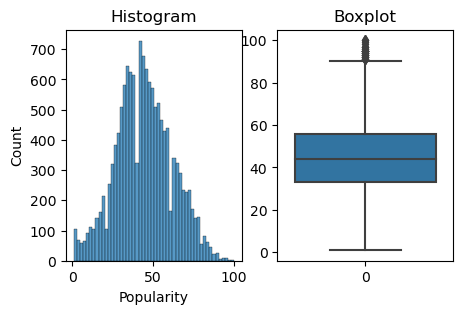

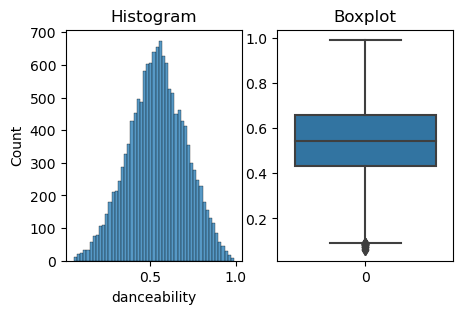

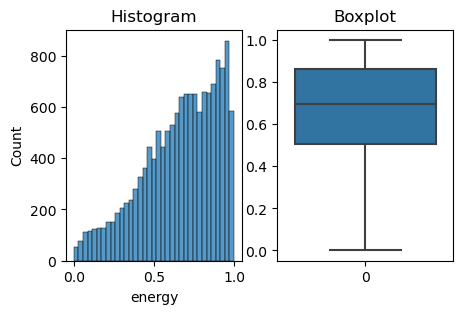

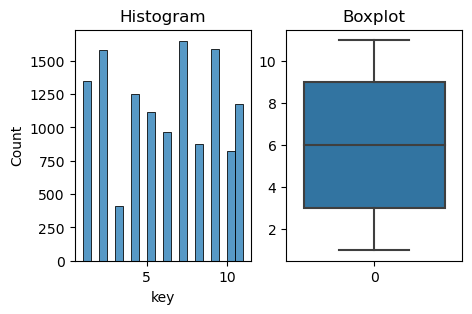

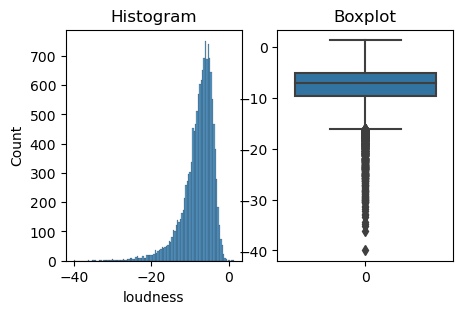

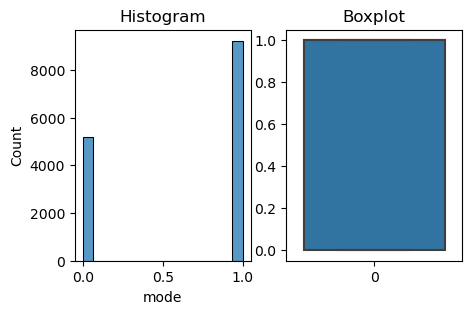

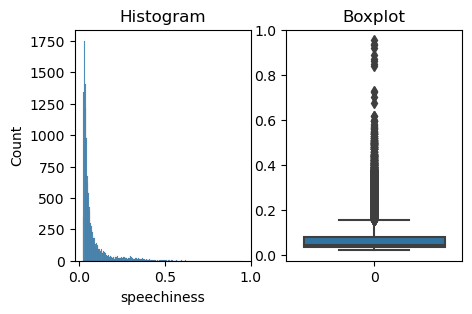

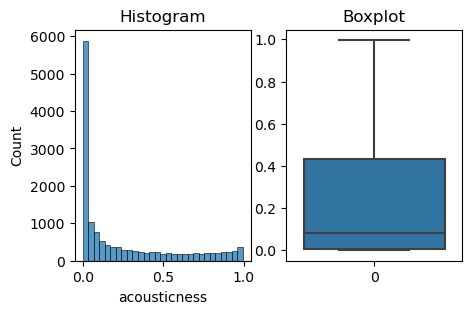

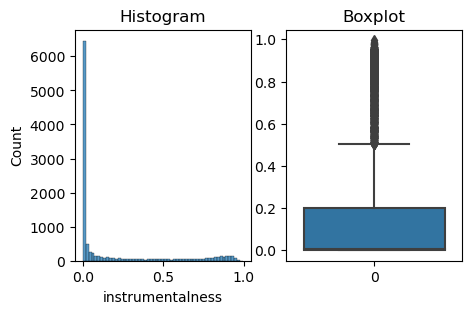

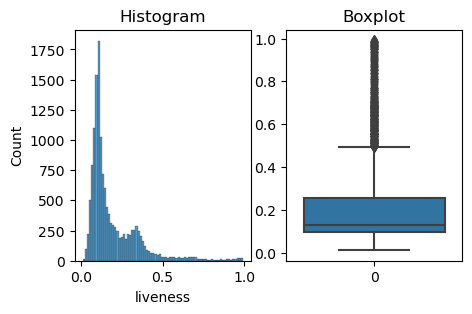

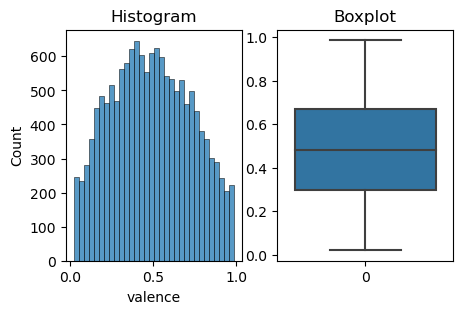

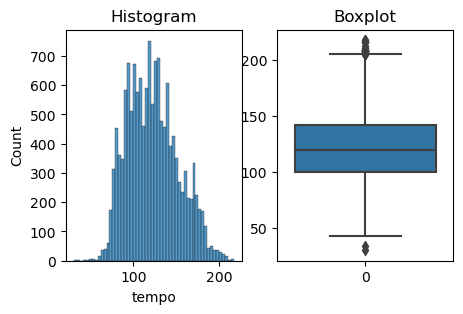

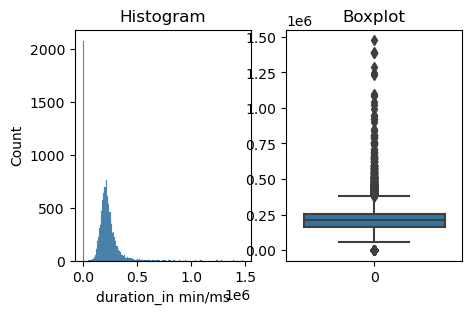

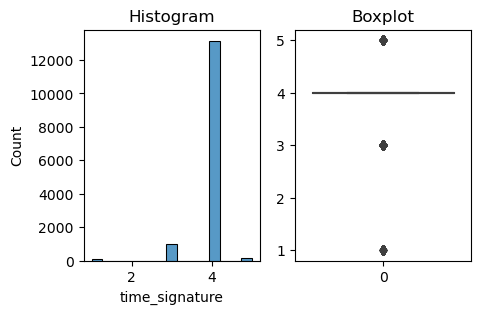

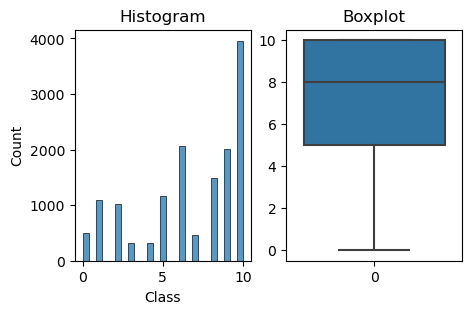

In [9]:
for i in range(2,len(train_data.columns)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 3))
    sns.histplot(train_data.iloc[:, i].values, ax=ax1)
    ax1.set_xlabel(train_data.columns[i])
    ax1.set_title('Histogram')
    sns.boxplot(train_data.iloc[:, i].values, ax=ax2)
    ax2.set_title('Boxplot')
    plt.show()

#### Most singer has songs

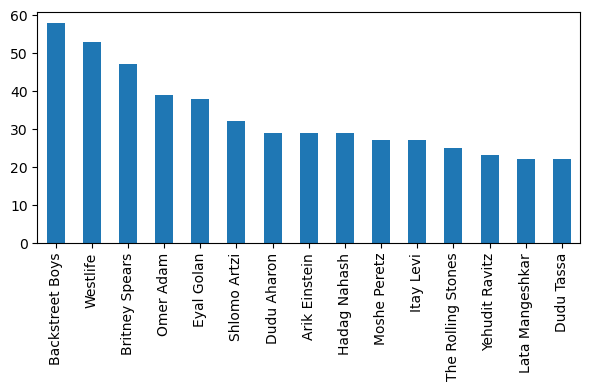

In [10]:
train_data['Artist Name'].value_counts()[:15].plot(kind='bar',figsize=(7,3))
plt.show()

## Handling missing values


In [11]:
train_data.isnull().sum()

Artist Name              0
Track Name               0
Popularity             333
danceability             0
energy                   0
key                   1609
loudness                 0
mode                     0
speechiness              0
acousticness             0
instrumentalness      3541
liveness                 0
valence                  0
tempo                    0
duration_in min/ms       0
time_signature           0
Class                    0
dtype: int64

## clean data
#### Show columns with missing values

In [12]:
for col in train_data.columns[train_data.isnull().any()].tolist():
    print(col + ": " + str(train_data[col].nunique()))

Popularity: 100
key: 11
instrumentalness: 3945


In [13]:
fill_mode = train_data['Popularity'].mode()
train_data['Popularity'] = train_data['Popularity'].fillna(fill_mode[0])

In [14]:
train_data['Popularity'].isna().sum()


0

In [15]:
fill_mode = train_data['key'].mode()
train_data['key'] = train_data['key'].fillna(fill_mode[0])

In [16]:
train_data['key'].isna().sum()

0

In [17]:
fill_median = train_data['instrumentalness'].median()
train_data['instrumentalness'] = train_data['instrumentalness'].fillna(fill_median)

train_data['instrumentalness'].isna().sum()

0

##### no missing value in columns

In [18]:
train_data.isna().sum()

Artist Name           0
Track Name            0
Popularity            0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
duration_in min/ms    0
time_signature        0
Class                 0
dtype: int64

In [19]:
train_data.drop_duplicates().head(2)

,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
Id,,,,,,,,,,,,,,,,,
1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.3780,0.00392,0.106,0.235,152.429,204947.0,4,9
2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.0272,0.04680,0.104,0.380,132.921,191956.0,4,6


# bulding model
1- split train data
2- Preprocessing

In [20]:
feature = train_data.drop(['Class','Artist Name','Track Name'],axis=1)
label = train_data['Class'].values

num_cols = feature.select_dtypes(include=np.number).columns
scaler = StandardScaler()
train_data[num_cols] = scaler.fit_transform(train_data[num_cols])
feature = train_data.drop(['Class','Artist Name','Track Name'],axis=1)

train_data

,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
Id,,,,,,,,,,,,,,,,,
1,Marina Maximilian,Not Afraid,-0.433615,-1.263390,-0.535777,0.965572,0.308549,-1.334049,-0.494173,0.422160,-0.478289,-0.563774,-1.049740,1.006641,0.043450,0.210416,9
2,The Black Keys,Howlin' for You,1.308558,1.098986,0.358445,1.624826,0.580657,0.749598,0.087129,-0.706136,-0.322158,-0.576333,-0.444231,0.346192,-0.072868,0.210416,6
3,Royal & the Serpent,phuck u,-0.143253,0.247081,0.600012,0.306318,0.445342,0.749598,-0.214678,-0.790508,1.819535,0.553950,0.620630,1.261369,-0.349708,0.210416,10
4,Detroit Blues Band,Missing You,-1.885426,-0.169809,-1.502046,0.306318,-1.678525,0.749598,-0.575203,2.123611,-0.415006,0.654419,0.061056,1.685203,0.877455,-2.571167,2
5,Coast Contra,My Lady,0.205182,0.132285,0.485585,-0.023309,0.691323,-1.334049,1.982527,-0.205029,-0.478289,0.095557,0.553815,-1.164094,0.483956,0.210416,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14392,NOISY,I Wish I Was A...,0.147109,0.386044,1.201811,-1.671444,1.216560,0.749598,0.819922,-0.775996,-0.491142,0.516274,0.695797,-0.090880,-0.043992,0.210416,10
14393,BLOODSPOT,Deadline Story (feat. Patrick Boos),-1.014340,-0.653160,1.223001,0.635945,0.104962,0.749598,-0.265175,-0.793604,1.510042,-0.631591,-1.183370,0.417728,0.733748,0.210416,8
14394,Cold Years,Too Far Gone,-1.304702,-0.773998,1.180620,1.624826,0.887517,0.749598,-0.326241,-0.787800,-0.492549,0.886755,0.357547,1.533057,-0.210997,0.210416,10


## 3-modeling


In [21]:
test_data = pd.read_csv('/kaggle/input/shai-music-genre-classification-2/test (2).csv',index_col='Id')
test_data.head()

,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
Id,,,,,,,,,,,,,,,,
14397,Juan Pablo Vega,Matando (feat. Vic Mirallas),NaN,0.691,0.670,2.0,-7.093,0,0.0941,0.075700,0.035200,0.1970,0.635,89.965,200000.0,4
14398,Kappi Kat,Baarish,14.0,0.461,0.777,2.0,-7.469,1,0.0306,0.388000,0.923000,0.2910,0.525,163.043,283909.0,4
14399,Plain White T's,Hey There Delilah,80.0,0.656,0.291,2.0,-10.572,1,0.0293,0.872000,NaN,0.1140,0.298,103.971,232533.0,4
14400,WALK THE MOON,Different Colors,52.0,0.480,0.826,NaN,-4.602,1,0.0397,0.000797,0.000001,0.1250,0.687,96.000,222053.0,4
14401,Peled,◊ß◊®◊ô◊ñ,23.0,0.734,0.729,1.0,-6.381,0,0.2830,0.147000,NaN,0.0672,0.805,76.030,118439.0,4


In [22]:
fill_mode = test_data['Popularity'].mode()
test_data['Popularity'] = test_data['Popularity'].fillna(fill_mode[0])
test_data['Popularity'].isna().sum()

0

In [23]:
fill_mode = test_data['key'].mode()
test_data['key'] = test_data['key'].fillna(fill_mode[0])

In [24]:
fill_median = test_data['instrumentalness'].median()
test_data['instrumentalness'] = test_data['instrumentalness'].fillna(fill_median)
test_data.head(3)

,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
Id,,,,,,,,,,,,,,,,
14397,Juan Pablo Vega,Matando (feat. Vic Mirallas),37.0,0.691,0.670,2.0,-7.093,0,0.0941,0.0757,0.035200,0.197,0.635,89.965,200000.0,4
14398,Kappi Kat,Baarish,14.0,0.461,0.777,2.0,-7.469,1,0.0306,0.3880,0.923000,0.291,0.525,163.043,283909.0,4
14399,Plain White T's,Hey There Delilah,80.0,0.656,0.291,2.0,-10.572,1,0.0293,0.8720,0.003755,0.114,0.298,103.971,232533.0,4


In [25]:
num_cols = test_data.select_dtypes(include=np.number).columns
scaler = StandardScaler()
test_data[num_cols] = scaler.fit_transform(test_data[num_cols])

test_data

,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
Id,,,,,,,,,,,,,,,,
14397,Juan Pablo Vega,Matando (feat. Vic Mirallas),-0.420582,0.864224,0.024909,-1.347050,0.213371,-1.284896,0.211787,-0.558137,-0.364217,-0.004528,0.614995,-1.089846,-0.029561,0.208774
14398,Kappi Kat,Baarish,-1.752496,-0.494844,0.484181,-1.347050,0.119744,0.778273,-0.613927,0.451016,2.859921,0.586601,0.162410,1.370568,0.712054,0.208774
14399,Plain White T's,Hey There Delilah,2.069518,0.657409,-1.601859,-1.347050,-0.652933,0.778273,-0.630831,2.014994,-0.478413,-0.526482,-0.771562,-0.618287,0.257976,0.208774
14400,WALK THE MOON,Different Colors,0.448057,-0.382574,0.694502,0.309612,0.833654,0.778273,-0.495596,-0.800175,-0.492046,-0.457307,0.828945,-0.886657,0.165350,0.208774
14401,Peled,◊ß◊®◊ô◊ñ,-1.231313,1.118310,0.278153,-1.678382,0.390666,-1.284896,2.668123,-0.327741,-0.478413,-0.820788,1.314445,-1.559014,-0.750425,0.208774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17992,Within Temptation,Stand My Ground,0.621785,-1.617553,0.866193,-0.353053,0.965629,-1.284896,-0.260235,-0.644737,-0.489283,-0.513904,-1.475126,1.795529,0.571330,0.208774
17993,Dikla,◊©◊ë◊ï◊¢◊ô◊ô◊ù,-0.362673,0.314687,0.110754,-0.353053,0.794808,-1.284896,2.928190,0.370232,-0.478413,-0.917004,0.689055,2.208606,-0.044587,0.208774
17994,Cut Copy,Hearts On Fire - Calvin Harris Remix,-1.520859,1.407851,0.668749,-1.678382,0.460140,0.778273,-0.375965,-0.801006,1.320121,-0.848458,-1.030770,0.224902,1.200849,0.208774


### model and predict value
1-LogisticRegression

In [26]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(feature, label)

LogisticRegression(max_iter=1000)

In [27]:
x_test = test_data.drop(['Artist Name','Track Name'],axis=1)
y_pred = log_model.predict(x_test)

y_pred

array([ 9,  6,  9, ...,  6,  2, 10])

In [28]:
acuel_class = pd.read_csv('/kaggle/input/shai-music-genre-classification-2/sample_submission (2).csv')
acuel_class_value = acuel_class.values[:,1]
acuel_class_value

array([ 6,  6,  9, ...,  1, 10, 10])

In [29]:
accuracy = accuracy_score(acuel_class_value, y_pred)
print("accuracy model:", accuracy)

accuracy model: 0.6375


In [30]:
#confution matrix
cm = confusion_matrix(acuel_class_value, y_pred)
print(cm)

[[130   0   0   8  14   0   0   4   0   3   2]
 [  0   0   4   0   0   8  30   0  10  13  83]
 [  0   0  98   0   0   2  14   1   0  25  58]
 [  6   0   0  57   3   1   0   2   0   0   1]
 [  7   0   0   5  49   0   0   0   0  13   0]
 [  0   0   6   0   0 220   3   0   0  37  17]
 [  0   0  20   0   0  17 176   3  22  84 182]
 [  8   0   0   1   0   0   0 100   0   0   0]
 [  0   0   0   0   0   0   6   0 199   0  82]
 [ 15   0  23   2  14  10   4   0   0 289 122]
 [  1   0  54   2  19   5  38   0 118  73 977]]


### 2-svc model

In [31]:
svm_model = SVC()
svm_model.fit(feature, label)

SVC()

In [32]:
scores = cross_val_score(svm_model, feature, label, cv=10)

# طباعة نتائج التقييم لكل طبقة
print("نتائج التقييم المتقاطع:", scores)

# حساب المتوسط والانحراف المعياري لنتائج التقييم
print("المتوسط:", scores.mean())
print("الانحراف المعياري:", scores.std())

نتائج التقييم المتقاطع: [0.54444444 0.53402778 0.52916667 0.51944444 0.50347222 0.49305556
 0.53022933 0.52675469 0.51633079 0.54343294]
المتوسط: 0.5240358852598255
الانحراف المعياري: 0.01558128174459282


In [33]:
y_pred_svm = svm_model.predict(x_test)
y_pred_svm

array([ 9,  6,  9, ...,  6,  2, 10])

In [34]:
accuracy = accuracy_score(acuel_class_value, y_pred_svm)
print("accuracy model:", accuracy)

accuracy model: 0.6969444444444445


In [35]:
cm = confusion_matrix(acuel_class_value, y_pred_svm)
print(cm)

[[ 133    0    0    8    8    0    0    3    0    7    2]
 [   0    2    3    0    0    8   29    0    5   11   90]
 [   0    0  102    0    0    2   11    0    0   21   62]
 [   8    0    0   55    3    2    0    2    0    0    0]
 [   8    0    0    2   57    0    0    0    0    5    2]
 [   0    0    3    0    0  241    2    0    0   26   11]
 [   0    2   14    0    0   17  211    1   12   70  177]
 [   3    0    0    0    1    0    0  105    0    0    0]
 [   0    0    0    0    0    0    5    0  177    1  104]
 [   7    0   19    0   10    8    8    0    0  341   86]
 [   0    0   24    1   13   10   31    0   57   66 1085]]


## 3-DecisionTreeClassifier

In [36]:
dt_model = DecisionTreeClassifier()
dt_model.set_params(criterion='entropy', max_depth=10, min_samples_split=10, min_samples_leaf=5)
dt_model.fit(feature, label)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=5,
                       min_samples_split=10)

In [37]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(dt_model, feature, label, cv=10)

# طباعة نتائج التقييم لكل طبقة
print("نتائج التقييم المتقاطع:", scores)

# حساب المتوسط والانحراف المعياري لنتائج التقييم
print("المتوسط:", scores.mean())
print("الانحراف المعياري:", scores.std())

نتائج التقييم المتقاطع: [0.46597222 0.48888889 0.48055556 0.46736111 0.44722222 0.47222222
 0.47880473 0.46977067 0.46490618 0.49131341]
المتوسط: 0.47270172187475873
الانحراف المعياري: 0.012247258042090089


In [38]:
y_pred_dt = dt_model.predict(x_test)
y_pred_dt

array([ 6,  6,  9, ...,  1,  2, 10])

In [39]:
accuracy = accuracy_score(acuel_class_value, y_pred_dt)
print("accuracy model:", accuracy)

accuracy model: 0.5947222222222223


In [40]:
cm = confusion_matrix(acuel_class_value, y_pred_dt)
print(cm)

[[111   0   0  11  23   0   0   4   0  12   0]
 [  0  15  13   0   0   6  34   0  17   6  57]
 [  0   4 105   0   0   4  29   0   0  17  39]
 [ 28   0   0  35   3   0   0   2   0   1   1]
 [ 10   0   0   1  46   0   0   0   0   9   8]
 [  0   1   8   0   0 223  10   0   0  26  15]
 [  0  29  44   0   0  15 215   0  25  50 126]
 [  2   0   0   5   0   0   1 101   0   0   0]
 [  0   1   0   0   0   1   4   0 219   0  62]
 [  7   1  57   0   4  15  61   0   0 241  93]
 [  3  12  95   0   8  14 107   1 132  85 830]]


## 4-RandomForestClassifier

In [41]:
rf_model = RandomForestClassifier(random_state=42,n_estimators=600)
rf_model.fit(feature, label)

RandomForestClassifier(n_estimators=600, random_state=42)

In [42]:
y_pred_rf = rf_model.predict(x_test)
y_pred_rf

array([ 6,  6,  9, ...,  1,  2, 10])

In [43]:
accuracy = accuracy_score(acuel_class_value, y_pred_rf)
print("accuracy RandomForestClassifier model: ", accuracy)

accuracy RandomForestClassifier model:  0.8116666666666666


In [44]:
cm = confusion_matrix(acuel_class_value, y_pred_rf)
print(cm)

[[ 143    0    0    2   11    0    0    0    0    4    1]
 [   0   97    0    0    0    4   15    0    5    0   27]
 [   0    0  133    0    0    1   10    0    0    9   45]
 [   6    0    0   53    9    0    0    0    0    1    1]
 [   2    0    0    1   64    0    0    0    0    3    4]
 [   0    0    0    0    0  254    2    0    0   20    7]
 [   0    4   10    0    0    5  348    0   15   29   93]
 [   2    0    0    0    0    0    1  106    0    0    0]
 [   0    0    0    0    0    0    3    0  257    1   26]
 [   4    0   18    0    4    5   11    0    0  378   59]
 [   1    2   16    0    5    5   32    0  103   34 1089]]


## 4-AdaBoostClassifier

In [45]:
ada_model = AdaBoostClassifier(random_state=42,n_estimators=45, learning_rate=0.3)
ada_model.fit(feature, label)

AdaBoostClassifier(learning_rate=0.3, n_estimators=45, random_state=42)

In [46]:
scores = cross_val_score(ada_model, feature, label, cv=10)

# طباعة نتائج التقييم لكل طبقة
print("نتائج التقييم المتقاطع:", scores)

# حساب المتوسط والانحراف المعياري لنتائج التقييم
print("المتوسط:", scores.mean())
print("الانحراف المعياري:", scores.std())

نتائج التقييم المتقاطع: [0.43402778 0.39861111 0.40208333 0.3875     0.4125     0.40972222
 0.40305768 0.40375261 0.39541348 0.41417651]
المتوسط: 0.4060844722415258
الانحراف المعياري: 0.012026693692131904


In [47]:
y_pred_ada = ada_model.predict(x_test)
y_pred_ada

array([ 6,  6,  9, ...,  6, 10, 10])

In [48]:
accuracy = accuracy_score(acuel_class_value, y_pred_ada)
print("دقة النموذج:", accuracy)

دقة النموذج: 0.5383333333333333


In [49]:
cm = confusion_matrix(acuel_class_value, y_pred_ada)
print(cm)

[[ 45   0   0   2   0   0   0   9   0 102   3]
 [  0   0   0   0   0   6  51   0   0  11  80]
 [  0   0   9   0   0   0  81   0   0  46  62]
 [ 11   0   0  11   0   0   0   1   0  47   0]
 [  0   0   0   0   0   0   0   0   0  73   1]
 [  0   0   0   0   0 202   4   0   0  62  15]
 [  0   0   0   0   0   7 311   0   0  73 113]
 [ 14   0   0   2   0   0   1  86   0   6   0]
 [  0   0   0   0   0   0  64   0   1   0 222]
 [  2   0   1   0   0  11  25   0   0 291 149]
 [  0   0   2   0   0   2 192   0   0 109 982]]


## RandomForestClassifier the best model